NicheNet training: differentiation study example
================

In this tutorial, we will demonstrate the procedure for the scenario
where you want to explore cell-cell communication differences between
cell types, instead of between two conditions of the same cell type.
This corresponds to the “Cell Localization” scenario in the flowchart
below:

<img src="./images/flowchart.svg" style="width:70.0%" />

### Load data and networks

We will be using the mouse liver scRNA-seq data generated in the
[Guilliams et al (2022)
paper](https://www.sciencedirect.com/science/article/pii/S0092867421014811).
A subset of this data will be used for this tutorial. The full dataset can
be accessed at the [Liver Cell Atlas](https://livercellatlas.org/).

We will look at cell-cell communication differences between Kupffer
cells, the resident liver macrophages, and bile duct and capsule
macrophages. This means that we are interested in identifying the
Kupffer cell-specific ligands important for its identity. We will be
focusing on the niche cells of KCs, which are liver sinusoidal
endothelial cells (LSECs), hepatocytes, and stellate cells. Therefore,
we will skip the sender-agnostic approach for this analysis.

In [1]:
from nichenetpy.prediction import LigandActivityPredictor
from nichenetpy.network import (
    LigandReceptorNetwork,
    WeightedNetwork
)
from nichenetpy.utils import (
    combine_by_key,
    combine_dicts,
    subset_matrix
)
from nichenetpy.extraction import (
    get_expressed_genes,
    subset_ann,
    get_weighted_ligand_receptor_links,
    get_lfc_celltype
)
from nichenetpy.gene_symbol import mouse_alias_info
from nichenetpy.visualization import (
    prepare_ligand_target_visualization,
    prepare_ligand_receptor_visualization,
    heatmap_2d,
    heatmap_1d
)
from nichenetpy.metrics import group_metrics
from nichenetpy.io import read_ligand_target_matrix

from itertools import cycle, chain

import anndata
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import os
import requests
import pickle
import session_info

Download the model files

In [2]:
model_path = os.path.normpath("./tutorial_files/model/mouse")
if not os.path.exists(model_path):
    os.makedirs(model_path)
filename = "nichenet_mouse.pkl"
file_path = os.path.join("./tutorial_files", filename)
if not os.path.exists(file_path):
    res = requests.get(f"https://zenodo.org/records/14887637/files/{filename}")
    with open(file_path, "wb") as file:
        file.write(res.content)

Download the AnnData objects

In [3]:
data_path = os.path.normpath("./tutorial_files/AnnData")
if not os.path.exists(data_path):
    os.makedirs(data_path)
filenames = [
    "subset_integrated_zonation_RNA.h5",
    "subset_integrated_zonation_SCT.h5"
]
for filename in filenames:
    file_path = os.path.join(data_path, filename)
    if not os.path.exists(file_path):
        res = requests.get(f"https://zenodo.org/records/15355774/files/{filename}")
        with open(file_path, "wb") as file:
            file.write(res.content)

In [4]:
with open("./tutorial_files/nichenet_mouse.pkl", "rb") as file:
    model = pickle.loads(file.read())
predictor = model["predictor"]
lr_network = model["lr_network"]
lr_sig = model["lr_sig"]

In [5]:
ann = {
    "RNA": anndata.io.read_h5ad(os.path.join(data_path, "subset_integrated_zonation_RNA.h5")),
    "SCT": anndata.io.read_h5ad(os.path.join(data_path, "subset_integrated_zonation_SCT.h5"))
}
for anndata in ann.values():
    mouse_alias_info.alias_to_symbol(anndata)

Define a “receiver” cell population. The receiver cell population can only consist of one cell type.

In [6]:
receiver = "KCs"

Determine which genes are expressed in the receiver cell population. The function get_expressed_genes considers genes to be expressed if they have non-zero counts in a certain percentage of the cell population (by default set at 10%). Users are also free to define expressed genes differently in a way that fits their data.

In [7]:
expressed_genes_receiver = set(get_expressed_genes(receiver, ann["RNA"], 0.1))

Get a list of all receptors available in the ligand-receptor network, and define expressed receptors as genes that are in the ligand-receptor network and expressed in the receiver.

In [8]:
all_receptors = lr_network.get_receptors()
expressed_receptors = all_receptors.intersection(expressed_genes_receiver)

While it is possible to get potential ligands as we did in the previous vignette, we would like to add an additional filter where we only consider ligands that are up-regulated in sender cells from the KC niche compared to other sender cells from the other niche. Thus, we perform a pairwise DE analysis between each sender in the KC niche and each sender in other niches (Cholangiocytes and fibroblast for the bile duct macrophage niche, and capsule fibroblasts and mesothelial cells for the capsule macrophage niche). For each sender in the KC niche, we only retain genes that are significantly upregulated compared to the other four senders.

In [9]:
sender_celltypes = ("LSECs_portal", "Hepatocytes_portal", "Stellate cells_portal")
other_niche_celltypes = ("Cholangiocytes", "Fibroblast 2", "Capsule fibroblasts", "Mesothelial cells")
expressed_genes_sender = set()
for sender_celltype in sender_celltypes:
    DE_genes = []
    for other_niche_celltype in other_niche_celltypes:
        group_metrics(
            ann["SCT"],
            group_oi=sender_celltype,
            group_ref=other_niche_celltype,
            groupby="celltype",
            layer="data",
            min_pct=0.1,
            min_abs_lfc=0.25
        )
        metrics = ann["SCT"].uns["group_metrics"]
        genes = metrics[
            metrics["pval_adj"] <= 0.05
        ]["gene"]
        DE_genes.append(set(genes))
    expressed_genes_sender.update(set.intersection(*DE_genes))
potential_ligands = set(lr_network.subset_sep(expressed_genes_sender, expressed_receptors).get_ligands())

Define the gene set of interest that represents the cell-cell communication event to be studied. Perform DE analysis between the cell type of interest (KCs) and other localizations of the cell type (bile duct and capsule macrophages). Similar to above, we only retain genes that are significantly upregulated in KCs compared to both conditions.

In [10]:
group_metrics(
    ann["SCT"],
    group_oi=receiver,
    group_ref="MoMac1",
    groupby="celltype",
    layer="data",
    min_pct=0.1,
    min_abs_lfc=0.25
)
DE_MoMac1 = ann["SCT"].uns["group_metrics"]
group_metrics(
    ann["SCT"],
    group_oi=receiver,
    group_ref="MoMac2",
    groupby="celltype",
    layer="data",
    min_pct=0.1,
    min_abs_lfc=0.25
)
DE_MoMac2 = ann["SCT"].uns["group_metrics"]
geneset = set(
    DE_MoMac1[
        DE_MoMac1["pval_adj"] <= 0.05
    ]["gene"]
).intersection(
    DE_MoMac2[
        DE_MoMac2["pval_adj"] <= 0.05
    ]["gene"]
)

Determine background genes. Instead of using the entire genome as the background like in the flowchart, we can actually use a more specific background gene set in this case, because we only have around 500 target genes and there are around 5,000 expressed genes in KCs. This means that the size of the background gene set is sufficiently larger than the gene set of interest.

In [11]:
background_expressed_genes = expressed_genes_receiver

### Ligand activity analysis and downstream prediction

Perform the ligand activity analysis, then sort the ligands based on the area under the precision-recall curve (AUPR).

In [12]:
ligand_activities = predictor.predict_ligand_activities(
    geneset=geneset,
    background_expressed_genes=background_expressed_genes,
    potential_ligands=potential_ligands
)
ligand_activities = sorted(
    ligand_activities.items(),
    key=lambda x : (-x[1]["aupr_corrected"], x[0])
)

Obtain the names of the top 30 ligands.

In [13]:
best_upstream_ligands = [e[0] for e in ligand_activities[:30]]

Infer which genes in the gene set of interest have the highest regulatory potential for each top-ranked ligand. The function get_weighted_ligand_target_links will return genes that are in the gene set of interest and are the top n targets of a ligand.

In [14]:
active_ligand_target_links = [
    predictor.get_weighted_ligand_target_links(ligand, geneset, n=200)
    for ligand in best_upstream_ligands
]
# combine weighted ligand-target links of different ligands
active_ligand_target_links = list(
    chain(
        *(zip(cycle([e["ligand"]]), e["target"], e["weight"]) for e in active_ligand_target_links)
    )
)

Similarly, identify which receptors have the highest interaction potential with the top-ranked ligands.

In [15]:
ligand_receptor_links = get_weighted_ligand_receptor_links(
    best_upstream_ligands,
    expressed_receptors,
    lr_network,
    lr_sig
)

### Visualizations

Prepare the weighted ligand-target data frame for visualization by transforming it into matrix. By default, regulatory potentials lower than the 25th percentile are set to zero for visualization clarity. This cutoff parameter can freely be tuned by the user.

In [16]:
ligand_target_vis, targets, ligands = prepare_ligand_target_visualization(
    predictor,
    active_ligand_target_links,
    cutoff=0.5
)

Order the rows to follow the rankings of the ligands, and the columns alphabetically.

In [17]:
target2id = dict(zip(targets, range(len(targets))))
ligand2id = dict(zip(ligands, range(len(ligands))))
ligand_target_vis = subset_matrix(
    ligand_target_vis,
    [target2id[target] for target in sorted({e[1] for e in active_ligand_target_links}.intersection(targets))],
    [ligand2id[ligand] for ligand in best_upstream_ligands if ligand in ligands]
)

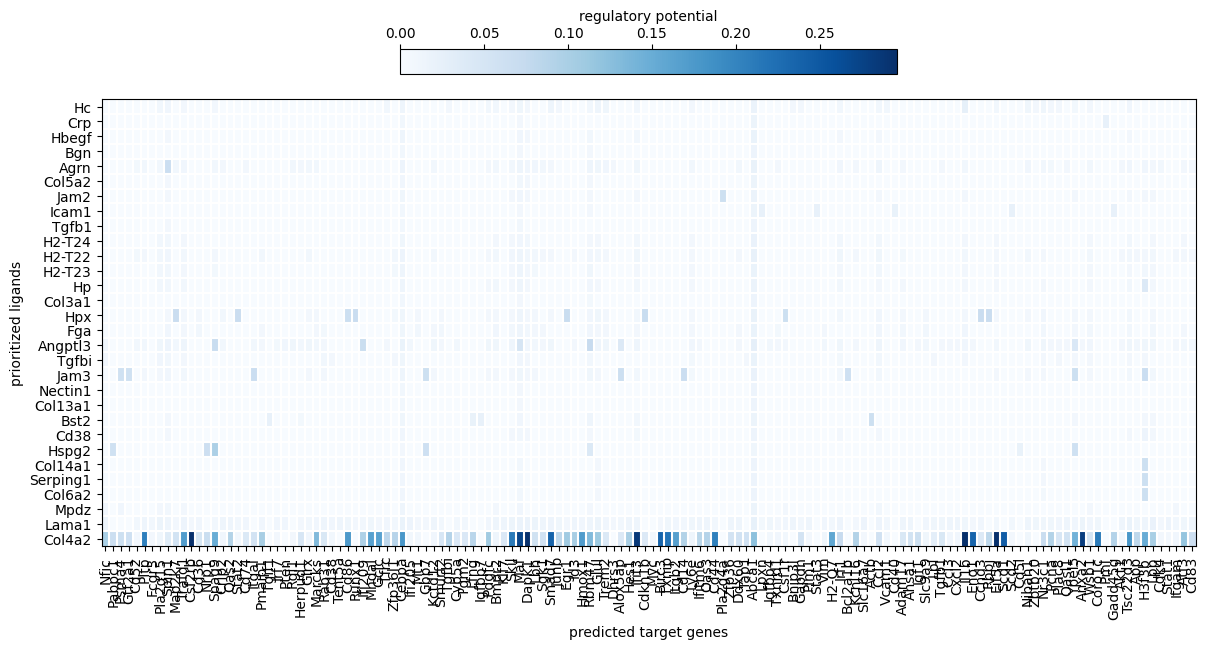

In [18]:
fig, ax = heatmap_2d(
    ligand_target_vis.transpose(),
    xlabels=targets,
    ylabels=ligands,
    xtitle="predicted target genes",
    ytitle="prioritized ligands",
    cbar_label="regulatory potential",
    cmap="Blues",
    figsize=(12, 6)
)
plt.show()

In [19]:
session_info.show()